# CalTech-101 Image Classifier
This project involves building an image classifier using the CalTech101 dataset. The dataset contains 101 object categories, each with a varying number of images. The goal is to train a deep learning model that can accurately classify images into their respective categories.

## Dataset Overview
The CalTech101 dataset consists of 9,146 images across 101 categories. Each category contains a different number of images, ranging from a few dozen to several hundred. The images vary in size, resolution        , and background complexity, making it a challenging dataset for image classification tasks.

## Project Structure
The project is organized into the following directories and files:
```
caltech101/
├── data/                  # Contains the CalTech101 dataset
├── notebooks/             # Jupyter notebooks for data exploration and model training
├── src/                   # Source code for data preprocessing, model training, and evaluation
├── models/                # Saved trained models
├── requirements.txt       # List of dependencies
├── README.md              # Project documentation
```

Dataset Link: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Caltech101.html#torchvision.datasets.Caltech101

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [91]:
import os
import random
import shutil
import json
import time
import glob
import gradio as gr
import sys
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchinfo import summary

# Point to the root directory to access the src folder
sys.path.append('..') 

from src.data_setup import create_dataloaders
from src.models import CustomCNN, create_vgg16, create_resnet50, create_efficientnet, create_convnext
from src.engine import train_and_log, create_writer
from src.utils import plot_loss_curves, predict_and_plot_random_image, save_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [92]:
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

torch version: 2.13.0+cu132
torchvision version: 0.28.0+cu132


In [93]:
# Set the precision for float32 matrix multiplication to 'high' for better performance and accuracy
torch.set_float32_matmul_precision('high')

In [94]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.benchmark = True  # Enable cuDNN auto-tuner for optimized performance on GPU
torch.backends.cudnn.deterministic = False

In [95]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Get Data

In [96]:
# Creating DataLoaders using the modularized function (will download the dataset to the '../data' folder if it doesn't exist)
train_dataloader, test_dataloader, class_names = create_dataloaders(data_dir="../data", batch_size=32)
num_classes = len(class_names)

print(f"Successfully loaded the CalTech101 dataset.")
print(f"Number of classes: {num_classes}")

Successfully loaded the CalTech101 dataset.
Number of classes: 102


In [97]:
from typing import Sized, cast

num_train_images = len(cast(Sized, train_dataloader.dataset))
num_test_images = len(cast(Sized, test_dataloader.dataset))

print(f"Number of training images: {num_train_images}")
print(f"Number of testing images: {num_test_images}")

Number of training images: 6941
Number of testing images: 1736


In [98]:
print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of testing batches: {len(test_dataloader)}")

Number of training batches: 217
Number of testing batches: 55


## Visualize Data

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

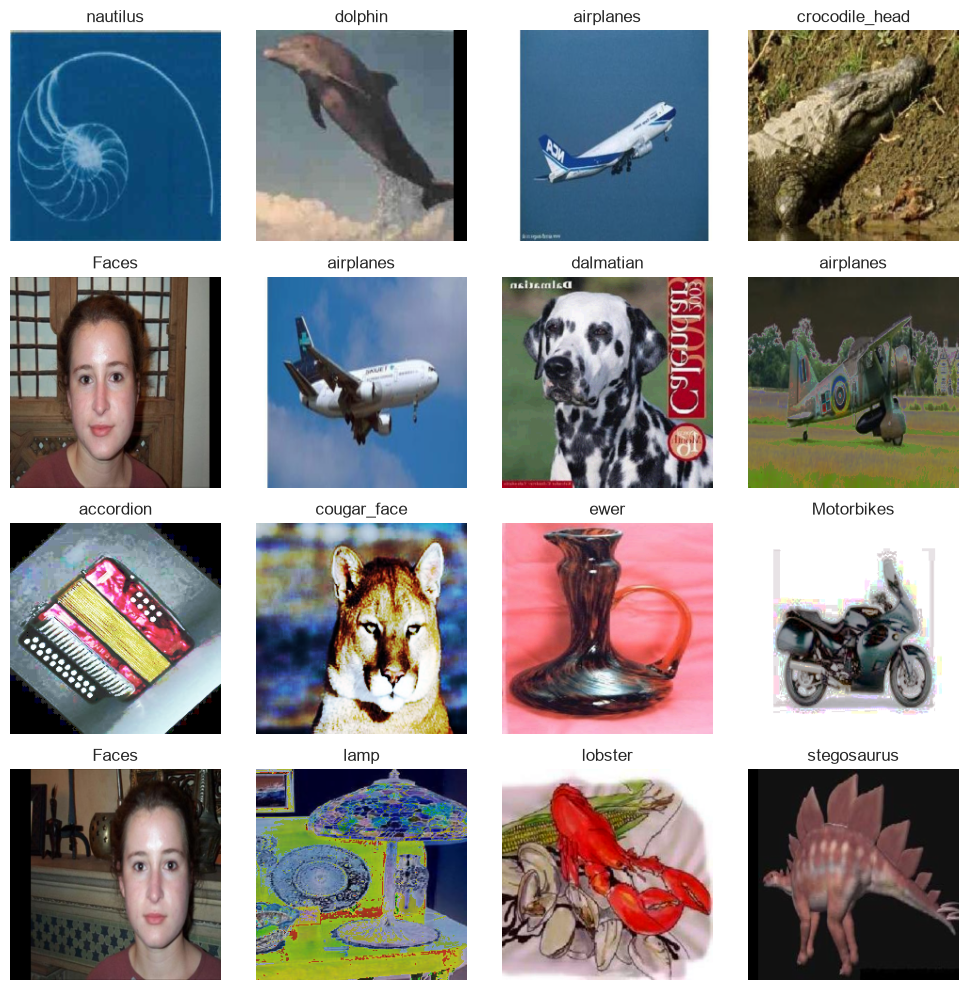

In [100]:
images, labels = next(iter(train_dataloader))

correct_class_names = train_dataloader.dataset.dataset.categories # type: ignore

# Normalization parameters used during preprocessing
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i in range(16):
    img = images[i]
    label = labels[i].item()
    
    img_unnorm = img * std + mean
    img_unnorm = torch.clamp(img_unnorm, 0, 1)
    
    # Permute the dimensions to (Height, Width, Channels) for Matplotlib
    img_plot = img_unnorm.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_plot)
    
    axes[i].set_title(correct_class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Training and Testing the Models

In [101]:
EPOCHS = 50

# Label smoothing helps prevent overfitting on datasets with a large number of classes
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

### Custom CNN

In [102]:
custom_cnn = CustomCNN(num_classes=num_classes).to(device)

In [103]:
summary(custom_cnn, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], device=device)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CustomCNN                                [32, 3, 224, 224]         [32, 102]                 --                        True
├─Sequential: 1-1                        [32, 3, 224, 224]         [32, 128, 28, 28]         --                        True
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 32, 224, 224]        896                       True
│    └─BatchNorm2d: 2-2                  [32, 32, 224, 224]        [32, 32, 224, 224]        64                        True
│    └─ReLU: 2-3                         [32, 32, 224, 224]        [32, 32, 224, 224]        --                        --
│    └─MaxPool2d: 2-4                    [32, 32, 224, 224]        [32, 32, 112, 112]        --                        --
│    └─Conv2d: 2-5                       [32, 32, 112, 112]        [32, 64, 112, 112]        18,496                    True
│    └─

#### Training the Model

In [104]:
compiled_cnn = torch.compile(custom_cnn)

optimizer_cnn = torch.optim.Adam(
    compiled_cnn.parameters(), 
    lr=1e-3, 
    weight_decay=1e-4, 
    fused=True
)

writer_cnn = create_writer(experiment_name="caltech101", model_name="custom_cnn_compiled")

cnn_results, train_time_cnn, test_time_cnn = train_and_log(
    model=compiled_cnn, 
    train_loader=train_dataloader, 
    test_loader=test_dataloader, 
    optimizer=optimizer_cnn, 
    loss_fn=loss_fn, 
    epochs=EPOCHS, 
    writer=writer_cnn, 
    device=device
)


Epoch: 1/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 3.8572 | Train Acc: 0.2435 | Test Loss: 3.2899 | Test Acc: 0.3432

Epoch: 2/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 1.6016 | Train Acc: 0.8182 | Test Loss: 1.7336 | Test Acc: 0.7614

Epoch: 50/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 1.5711 | Train Acc: 0.8255 | Test Loss: 1.7252 | Test Acc: 0.7580


In [105]:
minutes_train_cnn, seconds_train_cnn = divmod(train_time_cnn, 60)
minutes_test_cnn, seconds_test_cnn = divmod(test_time_cnn, 60)

if minutes_train_cnn > 0:
    print(f'Custom CNN Training Time: {int(minutes_train_cnn)} minutes and {seconds_train_cnn:.2f} seconds')
else:
    print(f'Custom CNN Training Time: {seconds_train_cnn:.2f} seconds')

if minutes_test_cnn > 0:
    print(f'Custom CNN Testing Time: {int(minutes_test_cnn)} minutes and {seconds_test_cnn:.2f} seconds')
else:
    print(f'Custom CNN Testing Time: {seconds_test_cnn:.2f} seconds')

Custom CNN Training Time: 7 minutes and 40.58 seconds
Custom CNN Testing Time: 1 minutes and 39.86 seconds


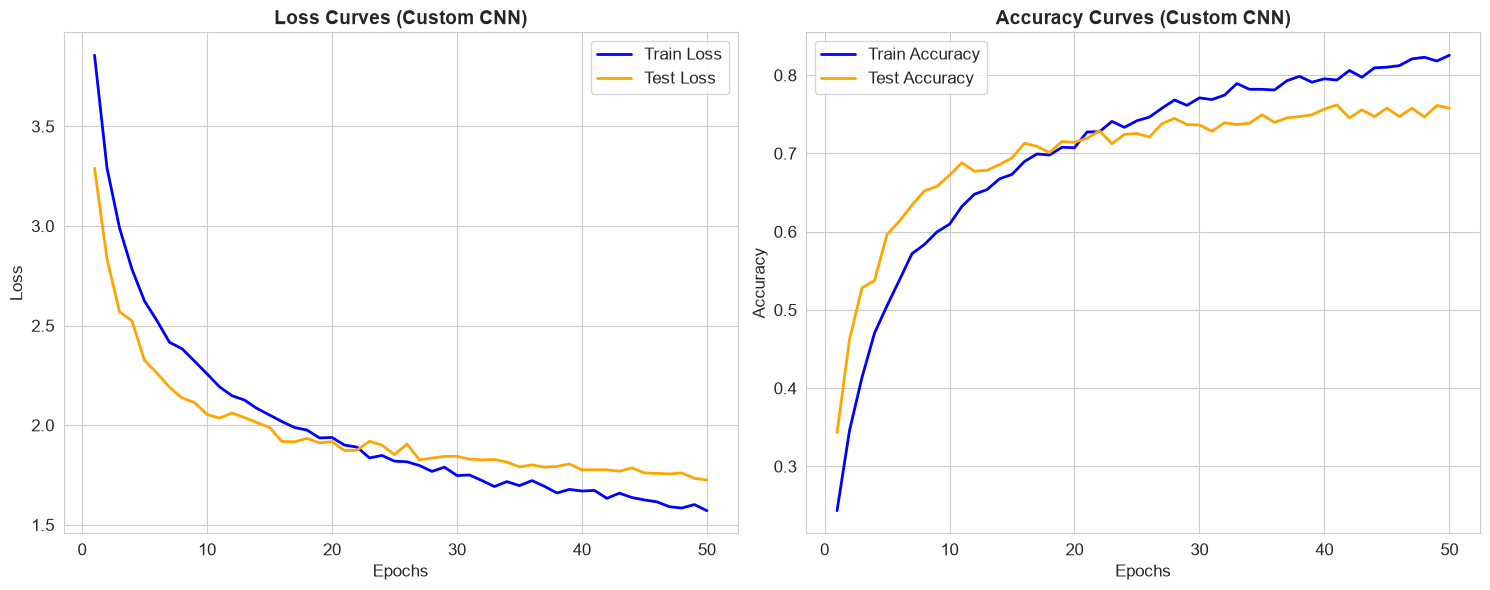

In [106]:
plot_loss_curves(cnn_results, model_type='Custom CNN')

#### Testing the Model

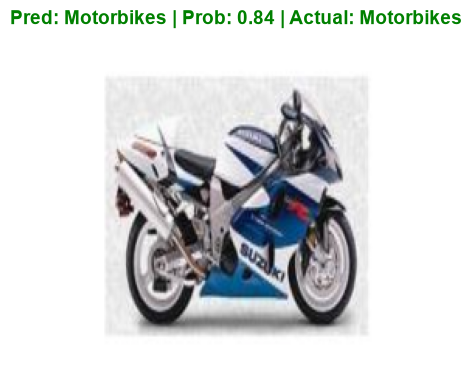

In [107]:
predict_and_plot_random_image(
    model=compiled_cnn, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

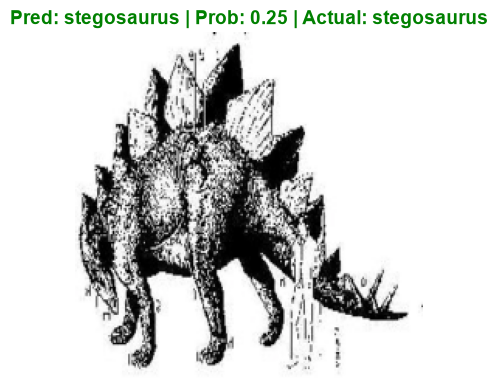

In [108]:
predict_and_plot_random_image(
    model=compiled_cnn, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

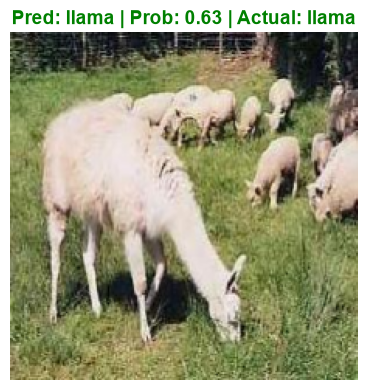

In [109]:
predict_and_plot_random_image(
    model=compiled_cnn, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

In [110]:
gc.collect()
torch.cuda.empty_cache()

### VGG16

In [111]:
vgg16 = create_vgg16(num_classes=num_classes).to(device)

In [112]:
summary(vgg16, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], device=device)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VGG                                      [32, 3, 224, 224]         [32, 102]                 --                        Partial
├─Sequential: 1-1                        [32, 3, 224, 224]         [32, 512, 7, 7]           --                        False
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 64, 224, 224]        (1,792)                   False
│    └─ReLU: 2-2                         [32, 64, 224, 224]        [32, 64, 224, 224]        --                        --
│    └─Conv2d: 2-3                       [32, 64, 224, 224]        [32, 64, 224, 224]        (36,928)                  False
│    └─ReLU: 2-4                         [32, 64, 224, 224]        [32, 64, 224, 224]        --                        --
│    └─MaxPool2d: 2-5                    [32, 64, 224, 224]        [32, 64, 112, 112]        --                        --
│  

#### Training the Model

In [113]:
compiled_vgg16 = torch.compile(vgg16)

optimizer_vgg16 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, compiled_vgg16.parameters()), 
    lr=1e-4, 
    weight_decay=1e-4, 
    fused=True
)

writer_vgg16 = create_writer(experiment_name="caltech101", model_name="vgg16_compiled")

vgg16_results, train_time_vgg16, test_time_vgg16 = train_and_log(
    model=compiled_vgg16, 
    train_loader=train_dataloader, 
    test_loader=test_dataloader, 
    optimizer=optimizer_vgg16, 
    loss_fn=loss_fn, 
    epochs=EPOCHS, 
    writer=writer_vgg16, 
    device=device
)


Epoch: 1/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 2.4580 | Train Acc: 0.5709 | Test Loss: 1.2727 | Test Acc: 0.9006

Epoch: 2/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 1.0794 | Train Acc: 0.9562 | Test Loss: 1.2170 | Test Acc: 0.9500

Epoch: 50/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 1.0897 | Train Acc: 0.9495 | Test Loss: 1.2383 | Test Acc: 0.9483


In [114]:
minutes_train_vgg16, seconds_train_vgg16 = divmod(train_time_vgg16, 60)
minutes_test_vgg16, seconds_test_vgg16 = divmod(test_time_vgg16, 60)

if minutes_train_vgg16 > 0:
    print(f'VGG16 Training Time: {int(minutes_train_vgg16)} minutes and {seconds_train_vgg16:.2f} seconds')
else:
    print(f'VGG16 Training Time: {seconds_train_vgg16:.2f} seconds')

if minutes_test_vgg16 > 0:
    print(f'VGG16 Testing Time: {int(minutes_test_vgg16)} minutes and {seconds_test_vgg16:.2f} seconds')
else:
    print(f'VGG16 Testing Time: {seconds_test_vgg16:.2f} seconds')

VGG16 Training Time: 17 minutes and 8.14 seconds
VGG16 Testing Time: 3 minutes and 19.02 seconds


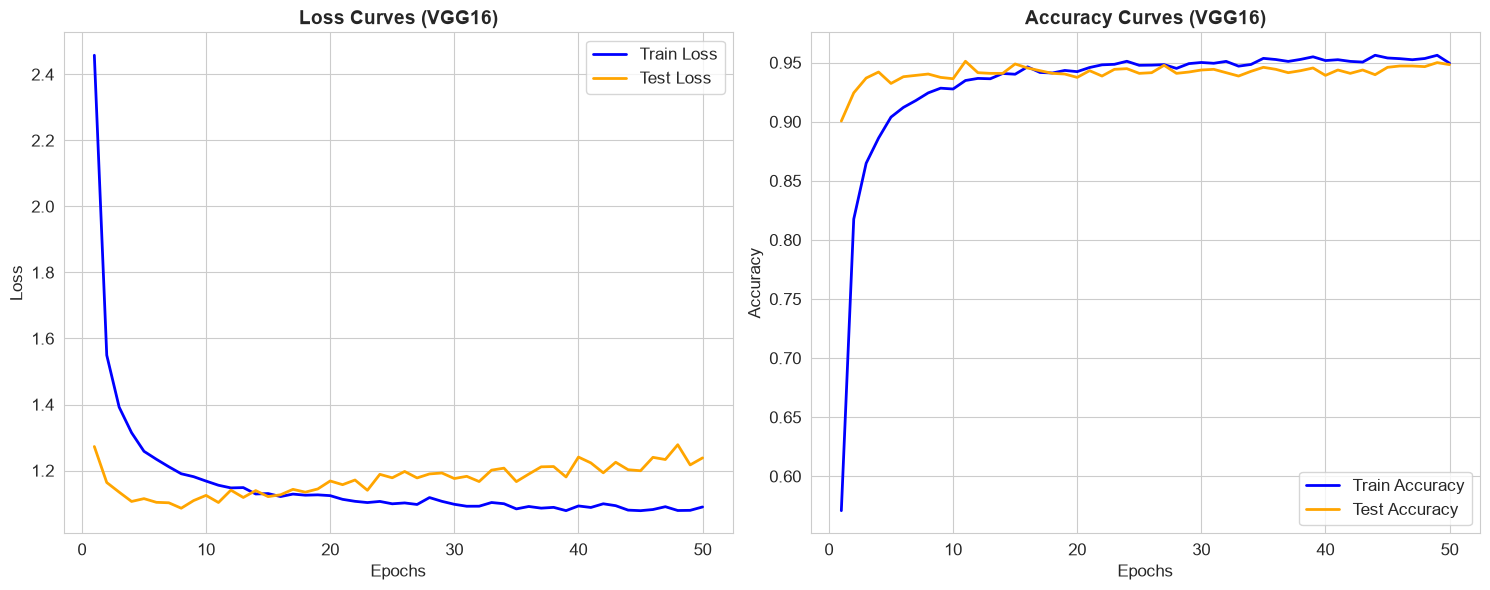

In [115]:
plot_loss_curves(vgg16_results, model_type='VGG16')

#### Testing the Model

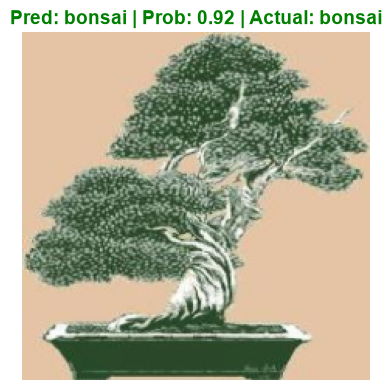

In [116]:
predict_and_plot_random_image(
    model=compiled_vgg16, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

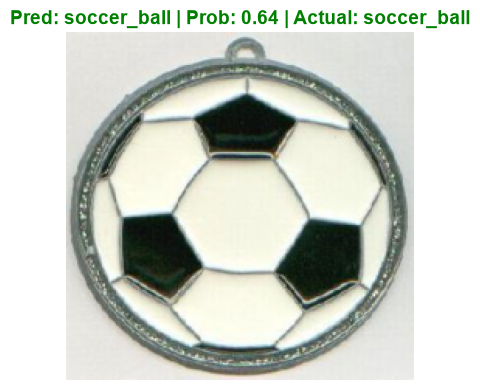

In [117]:
predict_and_plot_random_image(
    model=compiled_vgg16, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

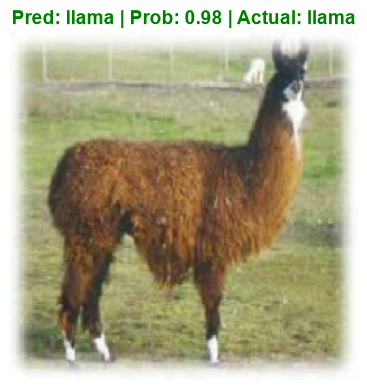

In [118]:
predict_and_plot_random_image(
    model=compiled_vgg16, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

In [119]:
gc.collect()
torch.cuda.empty_cache()

### ResNet50

In [120]:
resnet50 = create_resnet50(num_classes=num_classes).to(device)

In [121]:
summary(resnet50, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], device=device)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [32, 3, 224, 224]         [32, 102]                 --                        Partial
├─Conv2d: 1-1                            [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─ReLU: 1-3                              [32, 64, 112, 112]        [32, 64, 112, 112]        --                        --
├─MaxPool2d: 1-4                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─Sequential: 1-5                        [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False
│    └─Bottleneck: 2-1                   [32, 64, 56, 56]          [32, 256, 56, 56]         --                        False


#### Training the Model

In [122]:
compiled_resnet50 = torch.compile(resnet50)

optimizer_resnet50 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, compiled_resnet50.parameters()), 
    lr=1e-4, 
    weight_decay=1e-4, 
    fused=True
)

writer_resnet50 = create_writer(experiment_name="caltech101", model_name="resnet50_compiled")

resnet50_results, train_time_resnet50, test_time_resnet50 = train_and_log(
    model=compiled_resnet50, 
    train_loader=train_dataloader, 
    test_loader=test_dataloader, 
    optimizer=optimizer_resnet50, 
    loss_fn=loss_fn, 
    epochs=EPOCHS, 
    writer=writer_resnet50, 
    device=device
)


Epoch: 1/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 4.0154 | Train Acc: 0.1965 | Test Loss: 3.5934 | Test Acc: 0.3091

Epoch: 2/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 0.9996 | Train Acc: 0.9764 | Test Loss: 1.0512 | Test Acc: 0.9523

Epoch: 50/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 1.0030 | Train Acc: 0.9751 | Test Loss: 1.0515 | Test Acc: 0.9489


In [123]:
minutes_train_resnet50, seconds_train_resnet50 = divmod(train_time_resnet50, 60)
minutes_test_resnet50, seconds_test_resnet50 = divmod(test_time_resnet50, 60)

if minutes_train_resnet50 > 0:
    print(f'ResNet50 Training Time: {int(minutes_train_resnet50)} minutes and {seconds_train_resnet50:.2f} seconds')
else:
    print(f'ResNet50 CNN Training Time: {seconds_train_resnet50:.2f} seconds')

if minutes_test_resnet50 > 0:
    print(f'ResNet50 Testing Time: {int(minutes_test_resnet50)} minutes and {seconds_test_resnet50:.2f} seconds')
else:
    print(f'ResNet50 Testing Time: {seconds_test_resnet50:.2f} seconds')

ResNet50 Training Time: 7 minutes and 56.96 seconds
ResNet50 Testing Time: 1 minutes and 52.34 seconds


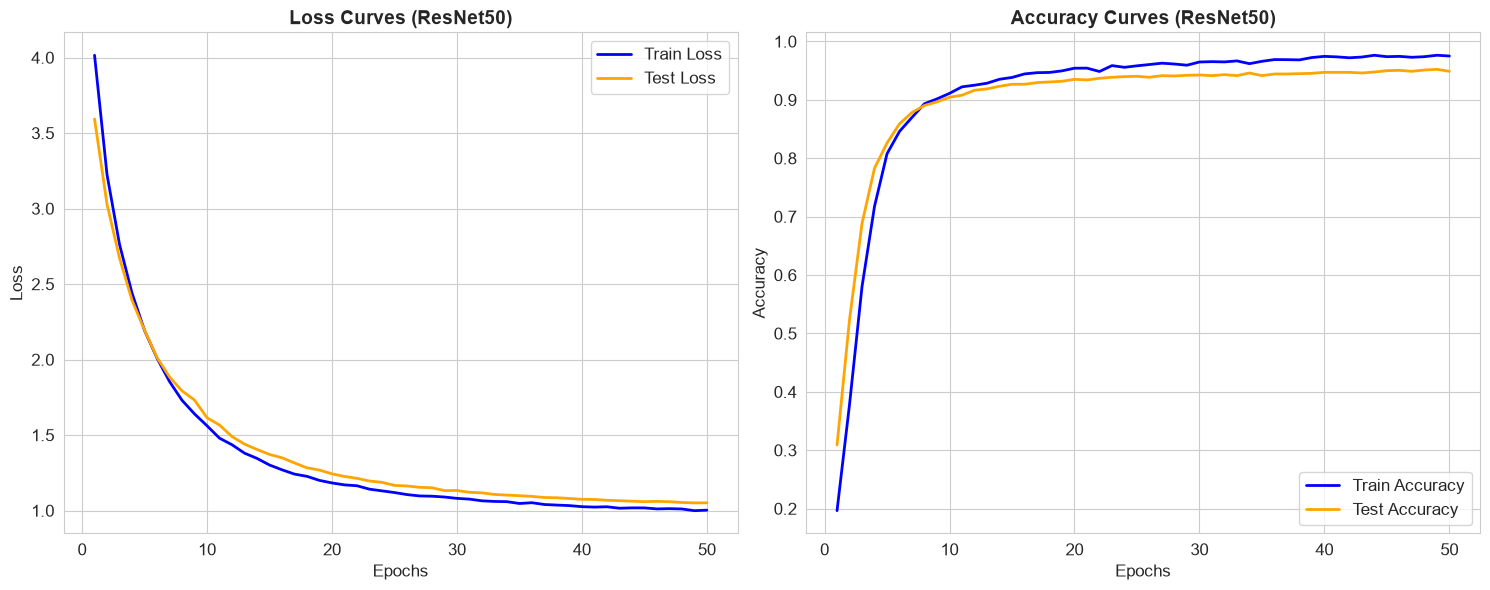

In [124]:
plot_loss_curves(resnet50_results, model_type='ResNet50')

#### Testing the Model

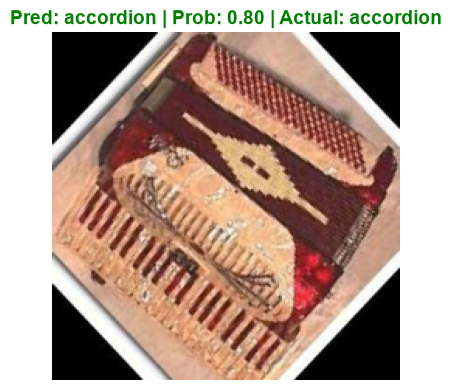

In [125]:
predict_and_plot_random_image(
    model=compiled_resnet50, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

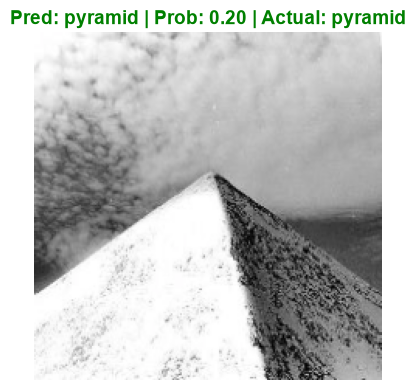

In [126]:
predict_and_plot_random_image(
    model=compiled_resnet50, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

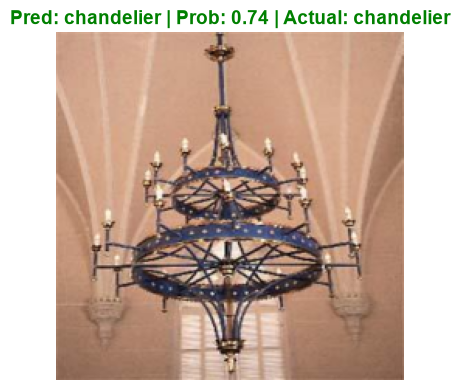

In [127]:
predict_and_plot_random_image(
    model=compiled_resnet50, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

In [128]:
gc.collect()
torch.cuda.empty_cache()

### EfficientNet-V2

In [129]:
effnetv2 = create_efficientnet(num_classes=num_classes).to(device)

In [130]:
summary(effnetv2, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], device=device)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 102]                 --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 24, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 24, 112, 112]        (648)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 24, 112, 112]        [32, 24, 112, 112]        (48)                      False
│    │    └─SiLU: 3-3                                   [32, 24, 112, 112]        [32, 24, 112, 112]        --                        --
│    └─Sequential

#### Training the Model

In [131]:
compiled_effnetv2 = torch.compile(effnetv2)

optimizer_effnetv2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, compiled_effnetv2.parameters()), 
    lr=1e-4, 
    weight_decay=1e-4, 
    fused=True
)

writer_effnetv2 = create_writer(experiment_name="caltech101", model_name="effnetv2_compiled")

effnetv2_results, train_time_effnetv2, test_time_effnetv2 = train_and_log(
    model=compiled_effnetv2, 
    train_loader=train_dataloader, 
    test_loader=test_dataloader, 
    optimizer=optimizer_effnetv2, 
    loss_fn=loss_fn, 
    epochs=EPOCHS, 
    writer=writer_effnetv2, 
    device=device
)


Epoch: 1/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 4.1643 | Train Acc: 0.3335 | Test Loss: 3.7349 | Test Acc: 0.7125

Epoch: 2/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 1.0682 | Train Acc: 0.9388 | Test Loss: 1.0841 | Test Acc: 0.9182

Epoch: 50/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 1.0806 | Train Acc: 0.9370 | Test Loss: 1.0852 | Test Acc: 0.9222


In [132]:
minutes_train_effnetv2, seconds_train_effnetv2 = divmod(train_time_effnetv2, 60)
minutes_test_effnetv2, seconds_test_effnetv2 = divmod(test_time_effnetv2, 60)

if minutes_train_effnetv2 > 0:
    print(f'EfficientNet-V2 Training Time: {int(minutes_train_effnetv2)} minutes and {seconds_train_effnetv2:.2f} seconds')
else:
    print(f'EfficientNet-V2 Training Time: {seconds_train_effnetv2:.2f} seconds')

if minutes_test_effnetv2 > 0:
    print(f'EfficientNet-V2 Testing Time: {int(minutes_test_effnetv2)} minutes and {seconds_test_effnetv2:.2f} seconds')
else:
    print(f'EfficientNet-V2 Testing Time: {seconds_test_effnetv2:.2f} seconds')

EfficientNet-V2 Training Time: 9 minutes and 1.36 seconds
EfficientNet-V2 Testing Time: 2 minutes and 1.45 seconds


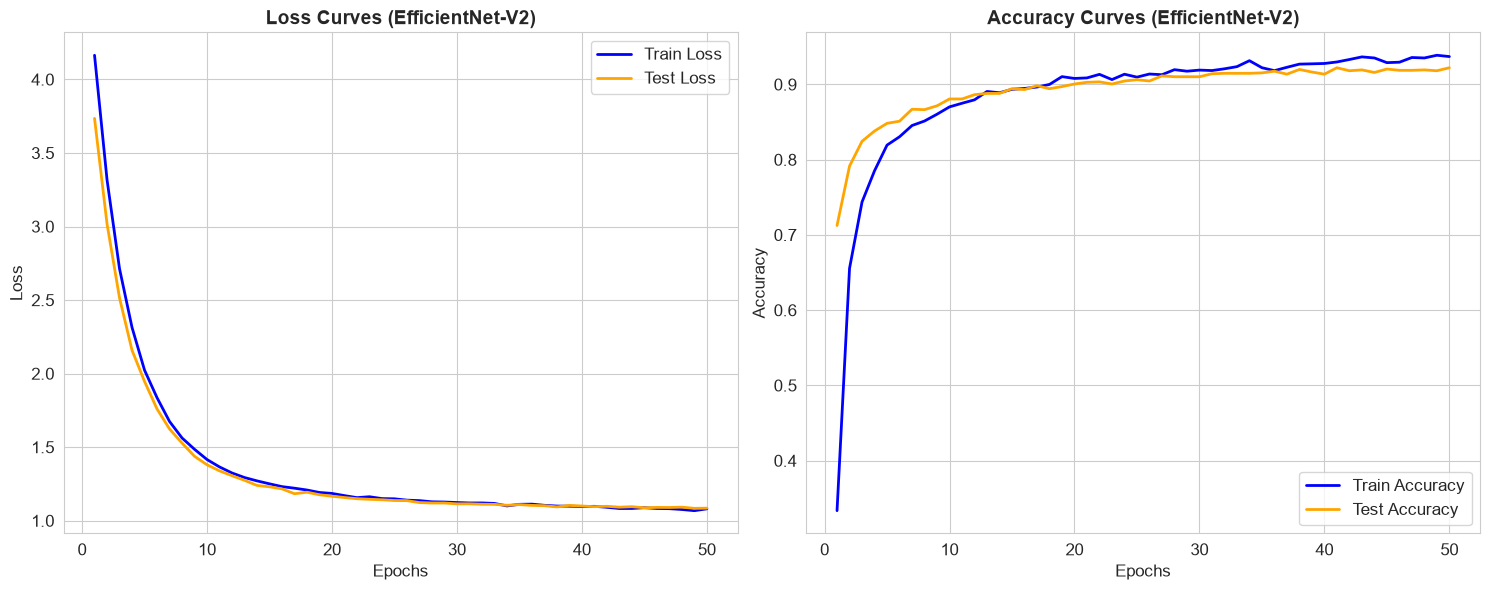

In [133]:
plot_loss_curves(effnetv2_results, model_type='EfficientNet-V2')

#### Testing the Model

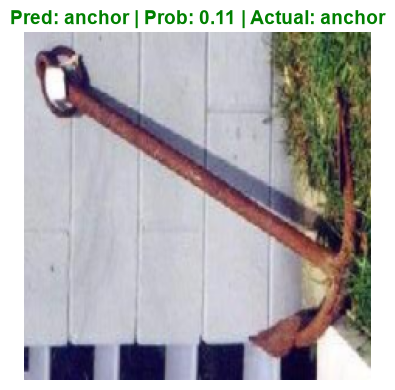

In [134]:
predict_and_plot_random_image(
    model=compiled_effnetv2, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

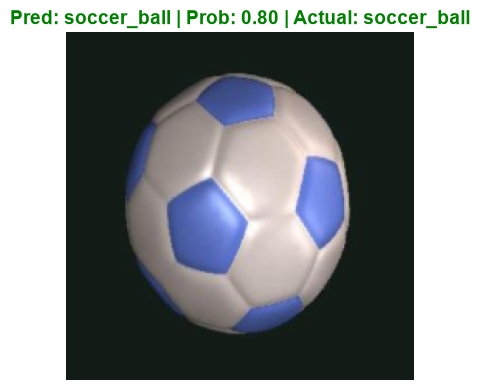

In [135]:
predict_and_plot_random_image(
    model=compiled_effnetv2, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

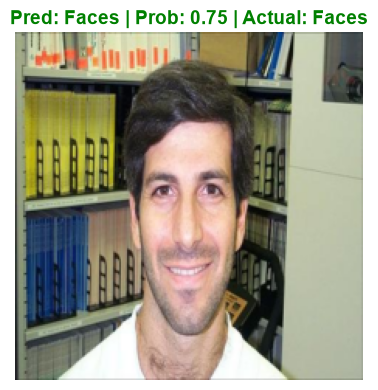

In [136]:
predict_and_plot_random_image(
    model=compiled_effnetv2, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

In [137]:
gc.collect()
torch.cuda.empty_cache()

### ConvNeXt

In [138]:
convnext = create_convnext(num_classes=num_classes).to(device)

In [139]:
summary(convnext, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"], device=device)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
ConvNeXt                                      [32, 3, 224, 224]         [32, 102]                 --                        Partial
├─Sequential: 1-1                             [32, 3, 224, 224]         [32, 768, 7, 7]           --                        False
│    └─Conv2dNormActivation: 2-1              [32, 3, 224, 224]         [32, 96, 56, 56]          --                        False
│    │    └─Conv2d: 3-1                       [32, 3, 224, 224]         [32, 96, 56, 56]          (4,704)                   False
│    │    └─LayerNorm2d: 3-2                  [32, 96, 56, 56]          [32, 96, 56, 56]          (192)                     False
│    └─Sequential: 2-2                        [32, 96, 56, 56]          [32, 96, 56, 56]          --                        False
│    │    └─CNBlock: 3-3                      [32, 96, 56, 56]          [32, 96, 56,

#### Training the Model

In [140]:
compiled_convnext = torch.compile(convnext)

optimizer_convnext = torch.optim.Adam(
    filter(lambda p: p.requires_grad, compiled_convnext.parameters()), 
    lr=1e-4, 
    weight_decay=1e-4, 
    fused=True
)

writer_convnext = create_writer(experiment_name="caltech101", model_name="convnext_compiled")

convnext_results, train_time_convnext, test_time_convnext = train_and_log(
    model=compiled_convnext, 
    train_loader=train_dataloader, 
    test_loader=test_dataloader, 
    optimizer=optimizer_convnext, 
    loss_fn=loss_fn, 
    epochs=EPOCHS, 
    writer=writer_convnext, 
    device=device
)


Epoch: 1/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 3.9988 | Train Acc: 0.3319 | Test Loss: 3.3026 | Test Acc: 0.6580

Epoch: 2/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 0.9098 | Train Acc: 0.9870 | Test Loss: 0.9329 | Test Acc: 0.9716

Epoch: 50/50


Training:   0%|          | 0/217 [00:00<?, ?it/s]

Testing:   0%|          | 0/55 [00:00<?, ?it/s]

Train Loss: 0.9127 | Train Acc: 0.9850 | Test Loss: 0.9330 | Test Acc: 0.9716


In [141]:
minutes_train_convnext, seconds_train_convnext = divmod(train_time_convnext, 60)
minutes_test_convnext, seconds_test_convnext = divmod(test_time_convnext, 60)

if minutes_train_convnext > 0:
    print(f'ConvNeXt Training Time: {int(minutes_train_convnext)} minutes and {seconds_train_convnext:.2f} seconds')
else:
    print(f'ConvNeXt Training Time: {seconds_train_convnext:.2f} seconds')

if minutes_test_convnext > 0:
    print(f'ConvNeXt Testing Time: {int(minutes_test_convnext)} minutes and {seconds_test_convnext:.2f} seconds')
else:
    print(f'ConvNeXt Testing Time: {seconds_test_convnext:.2f} seconds')

ConvNeXt Training Time: 7 minutes and 35.79 seconds
ConvNeXt Testing Time: 1 minutes and 48.53 seconds


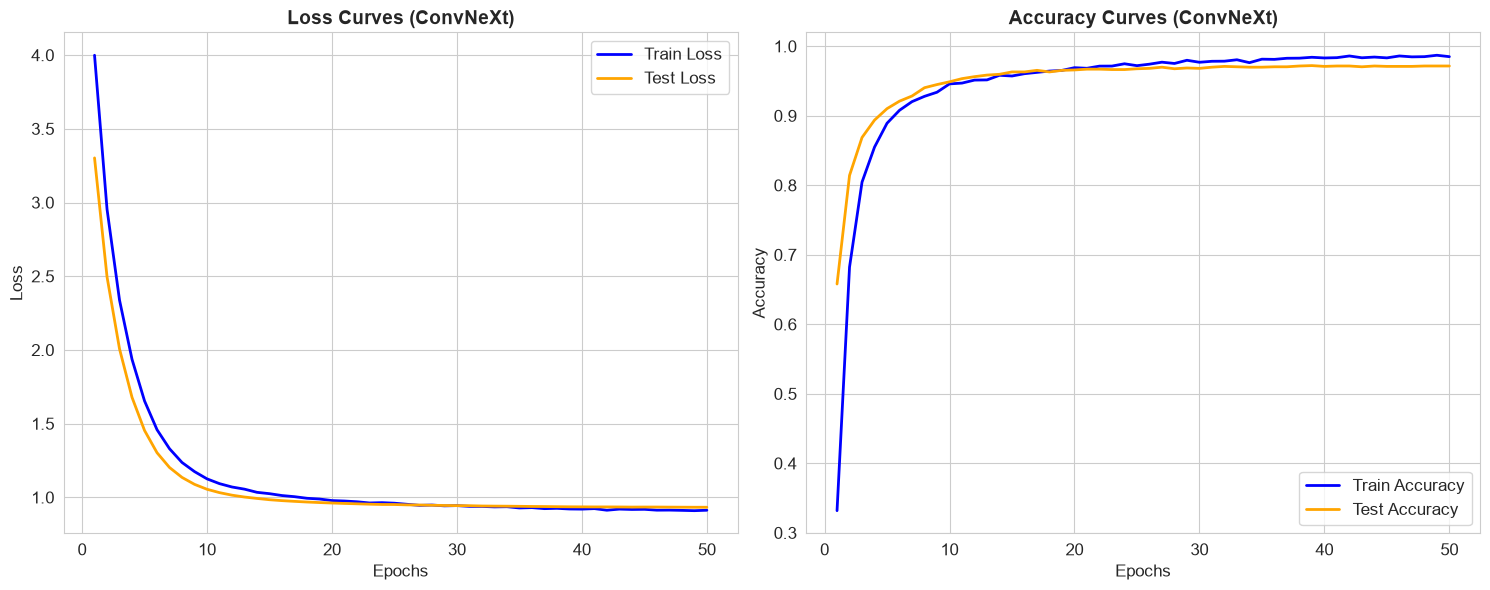

In [142]:
plot_loss_curves(convnext_results, model_type='ConvNeXt')

#### Testing the Model

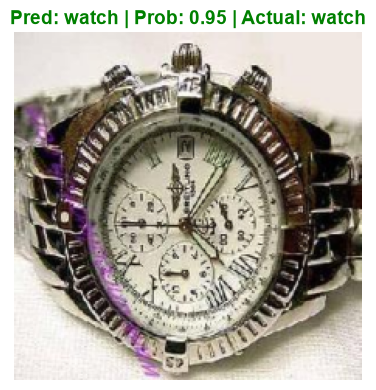

In [143]:
predict_and_plot_random_image(
    model=compiled_convnext, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

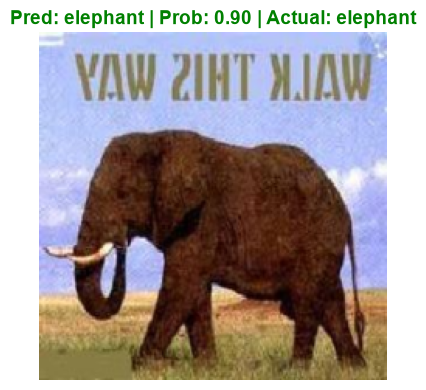

In [144]:
predict_and_plot_random_image(
    model=compiled_convnext, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

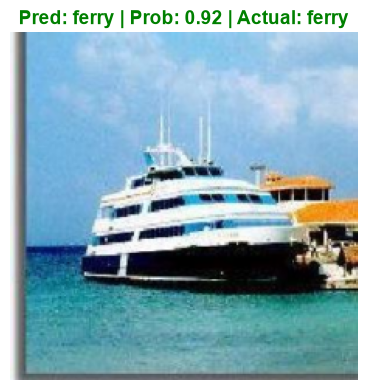

In [145]:
predict_and_plot_random_image(
    model=compiled_convnext, 
    dataset=test_dataloader.dataset, 
    class_names=correct_class_names, 
    device=device
)

In [146]:
gc.collect()
torch.cuda.empty_cache()

## Saving the Models

In [147]:
print("Saving all trained models to the 'models/' directory...")

save_model(model=custom_cnn, target_dir="../models", model_name="custom_cnn_caltech101.pth")
save_model(model=vgg16, target_dir="../models", model_name="vgg16_caltech101.pth")
save_model(model=resnet50, target_dir="../models", model_name="resnet50_caltech101.pth")
save_model(model=effnetv2, target_dir="../models", model_name="effnetv2_caltech101.pth")
save_model(model=convnext, target_dir="../models", model_name="convnext_caltech101.pth")

print("All models successfully saved!")

Saving all trained models to the 'models/' directory...
[INFO] Saving model to: ..\models\custom_cnn_caltech101.pth
[INFO] Saving model to: ..\models\vgg16_caltech101.pth
[INFO] Saving model to: ..\models\resnet50_caltech101.pth
[INFO] Saving model to: ..\models\effnetv2_caltech101.pth
[INFO] Saving model to: ..\models\convnext_caltech101.pth
All models successfully saved!


## Analysing the Performance of all Models

In [148]:
from src.utils import  get_advanced_metrics, get_model_size_mb, plot_speed_vs_performance, plot_top_errors, plot_gradcam

### General Summary

In [149]:
models_summary = {
    "Custom CNN": (compiled_cnn, train_time_cnn, test_time_cnn),
    "VGG16": (compiled_vgg16, train_time_vgg16, test_time_vgg16),
    "ResNet50": (compiled_resnet50, train_time_resnet50, test_time_resnet50),
    "EfficientNet-V2": (compiled_effnetv2, train_time_effnetv2, test_time_effnetv2),
    "ConvNeXt": (compiled_convnext, train_time_convnext, test_time_convnext)
}

results_list = []

for name, (model, train_time, test_time) in models_summary.items():
    acc, recall, precision, f1 = get_advanced_metrics(model, test_dataloader, device)
    
    results_list.append({
        "Model Name": name,
        "Total Training Time": f"{train_time / 60:.2f} min",
        "Total Testing Time": f"{test_time:.2f} sec",
        "Test Accuracy": f"{acc:.4f}",
        "Test Recall": f"{recall:.4f}",
        "Test Precision": f"{precision:.4f}",
        "Test F1 Score": f"{f1:.4f}"
    })

df_results = pd.DataFrame(results_list)
display(df_results)

,Model Name,Total Training Time,Total Testing Time,Test Accuracy,Test Recall,Test Precision,Test F1 Score
0,Custom CNN,7.68 min,99.86 sec,0.7563,0.7563,0.7616,0.7468
1,VGG16,17.14 min,199.02 sec,0.9476,0.9476,0.9513,0.9452
2,ResNet50,7.95 min,112.34 sec,0.9482,0.9482,0.9510,0.9479
3,EfficientNet-V2,9.02 min,121.45 sec,0.9211,0.9211,0.9265,0.9200
4,ConvNeXt,7.60 min,108.53 sec,0.9712,0.9712,0.9743,0.9711


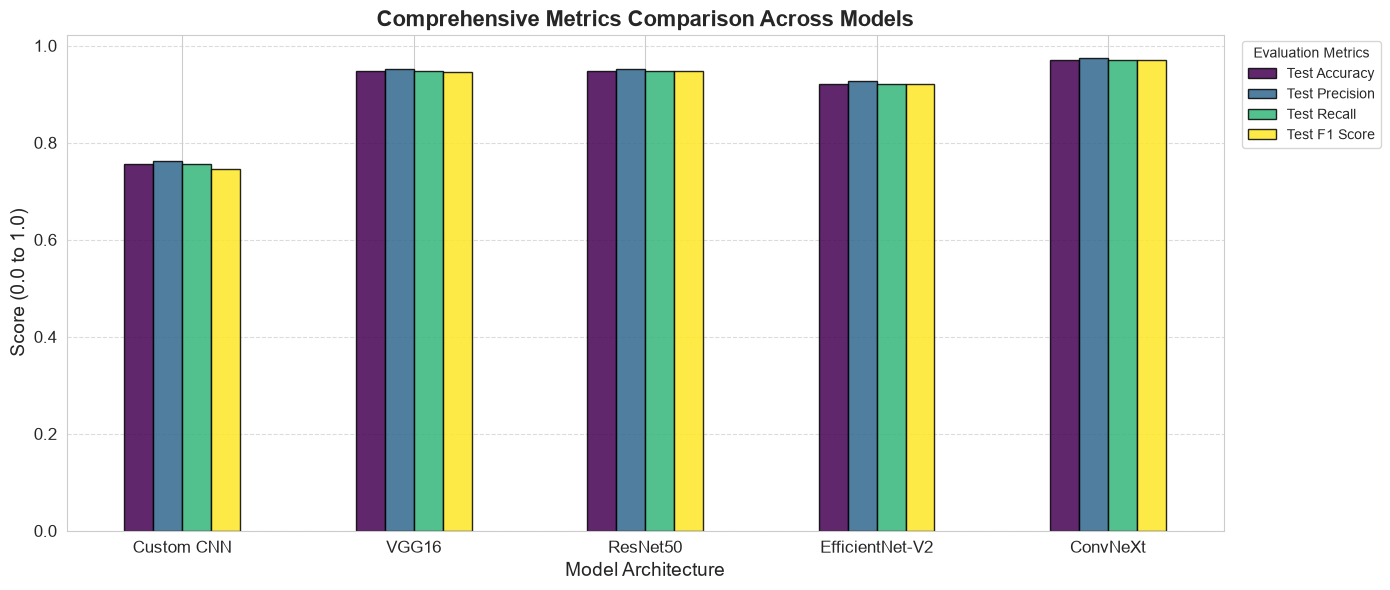

In [150]:
df_plot = df_results.copy()
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1 Score']
for col in metrics:
    df_plot[col] = df_plot[col].astype(float)

ax = df_plot.set_index("Model Name")[metrics].plot(
    kind='bar', 
    figsize=(14, 6), 
    colormap='viridis', 
    edgecolor='black',
    alpha=0.85
)

plt.title('Comprehensive Metrics Comparison Across Models', fontsize=16, fontweight='bold')
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xlabel('Model Architecture', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.legend(title="Evaluation Metrics", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Inference Speed versus Performance

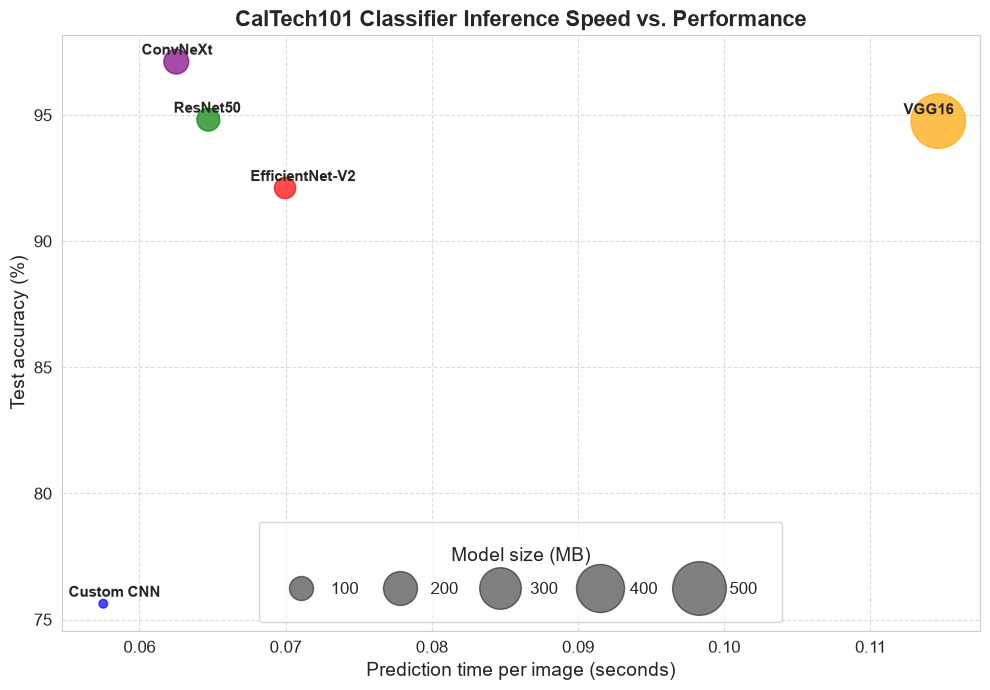

In [151]:
plot_speed_vs_performance(
    df_results=df_results, 
    models_summary=models_summary, 
    test_dataloader=test_dataloader
)

### Anlysis of Most Confused Class Pairs

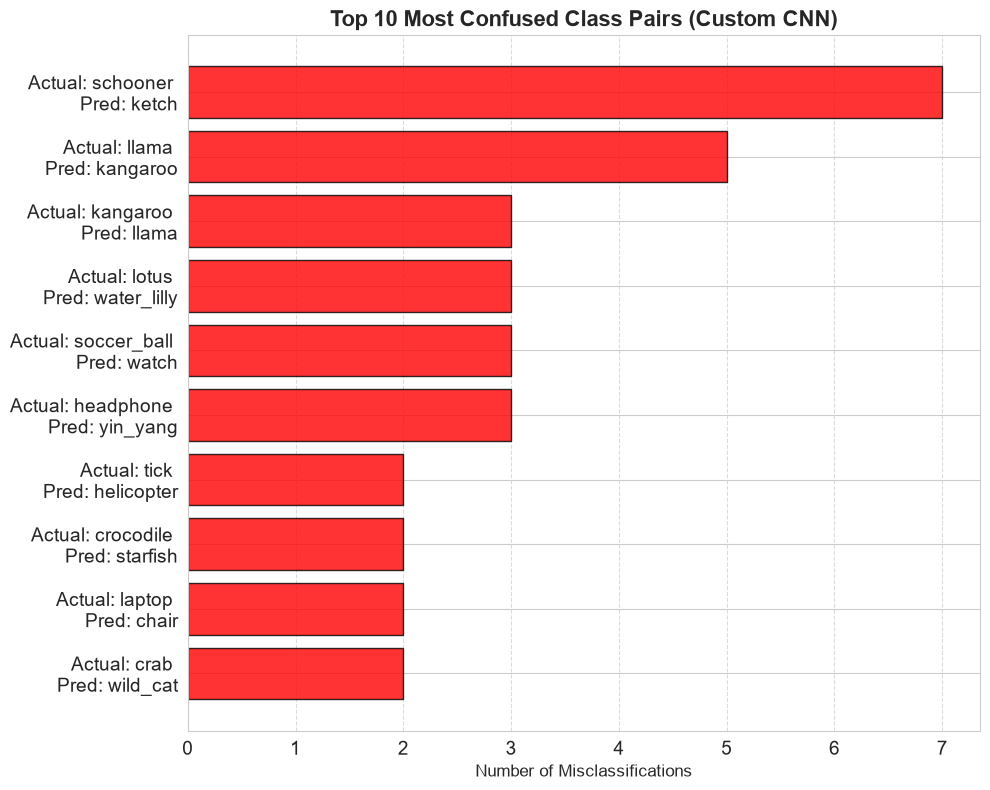

In [152]:
plot_top_errors(
    model=compiled_cnn, 
    dataloader=test_dataloader, 
    class_names=correct_class_names, 
    device=device,
    bcol='red',
    model_name="Custom CNN"
)

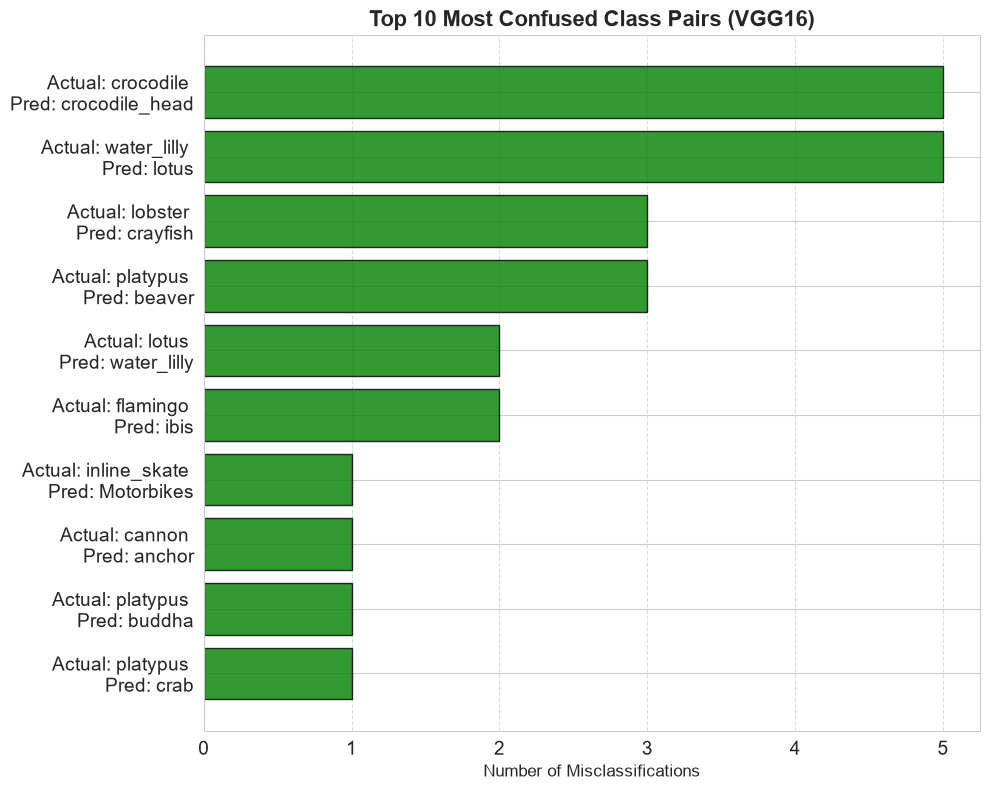

In [153]:
plot_top_errors(
    model=compiled_vgg16, 
    dataloader=test_dataloader, 
    class_names=correct_class_names, 
    device=device,
    bcol='green',
    model_name="VGG16"
)

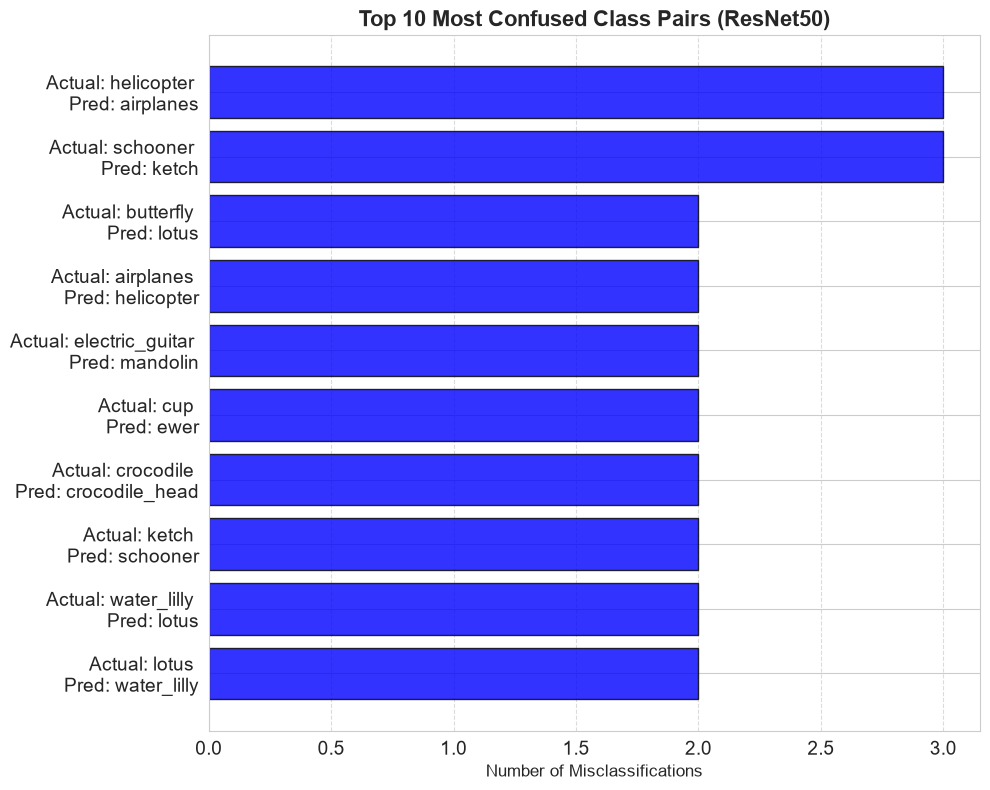

In [154]:
plot_top_errors(
    model=compiled_resnet50, 
    dataloader=test_dataloader, 
    class_names=correct_class_names, 
    device=device,
    bcol='blue',
    model_name="ResNet50"
)

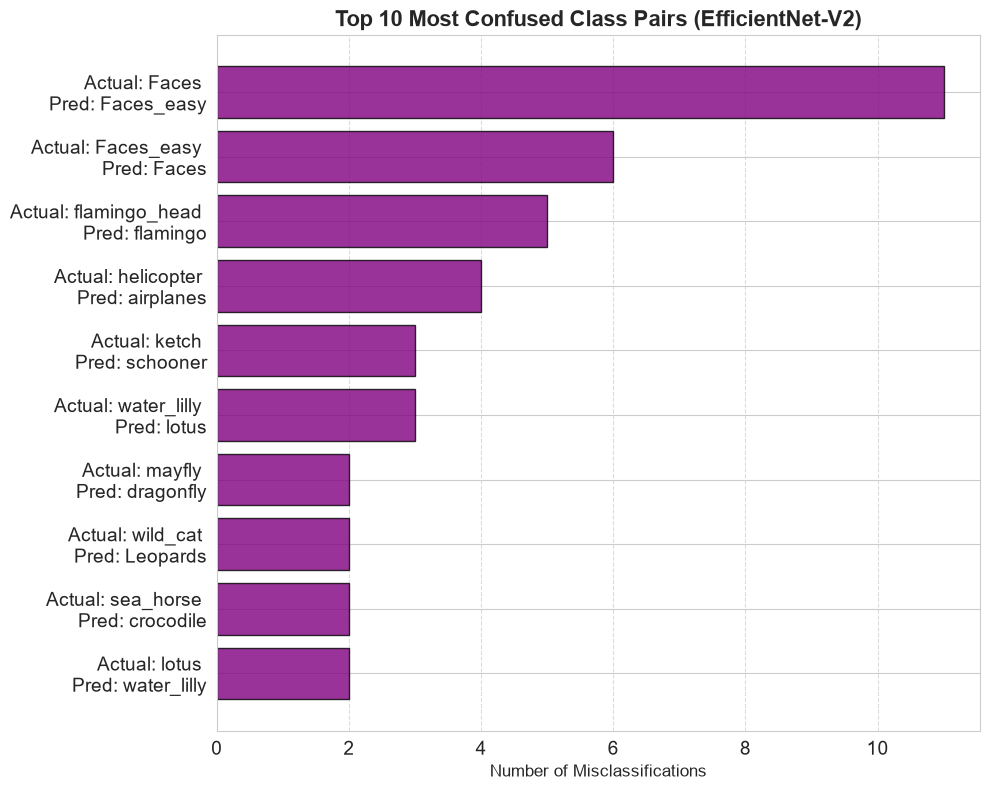

In [155]:
plot_top_errors(
    model=compiled_effnetv2, 
    dataloader=test_dataloader, 
    class_names=correct_class_names, 
    device=device,
    bcol='purple',
    model_name="EfficientNet-V2"
)

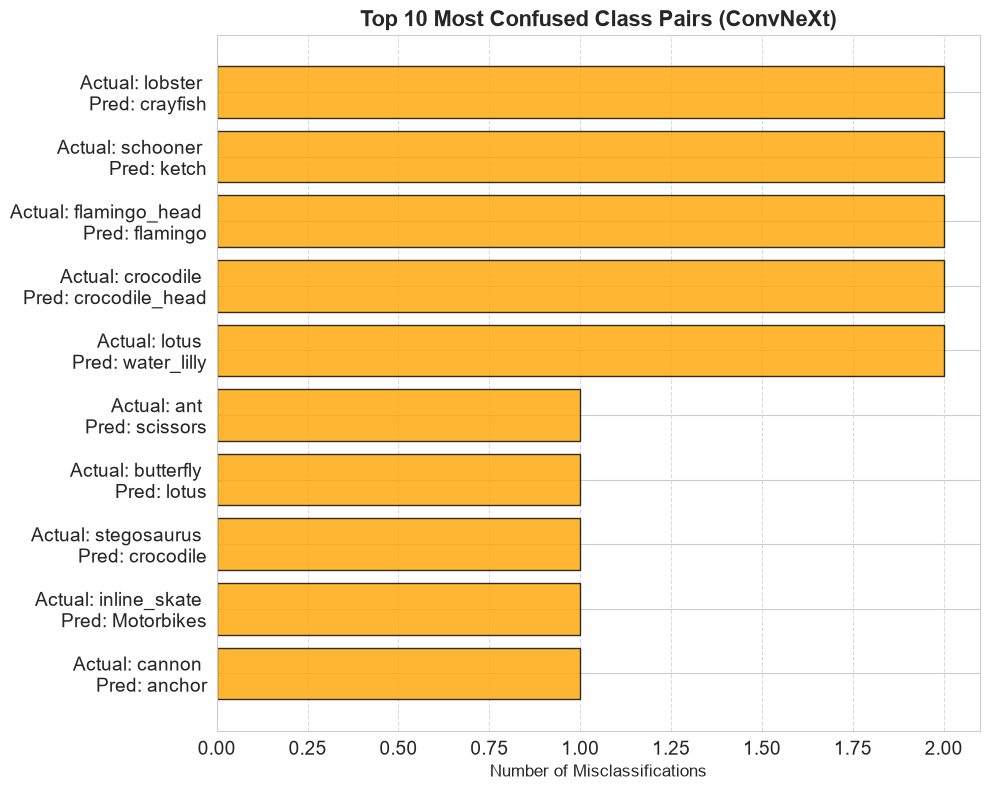

In [156]:
plot_top_errors(
    model=compiled_convnext, 
    dataloader=test_dataloader, 
    class_names=correct_class_names, 
    device=device,
    bcol='orange',
    model_name="ConvNeXt"
)

### Grad-CAM Heatmaps

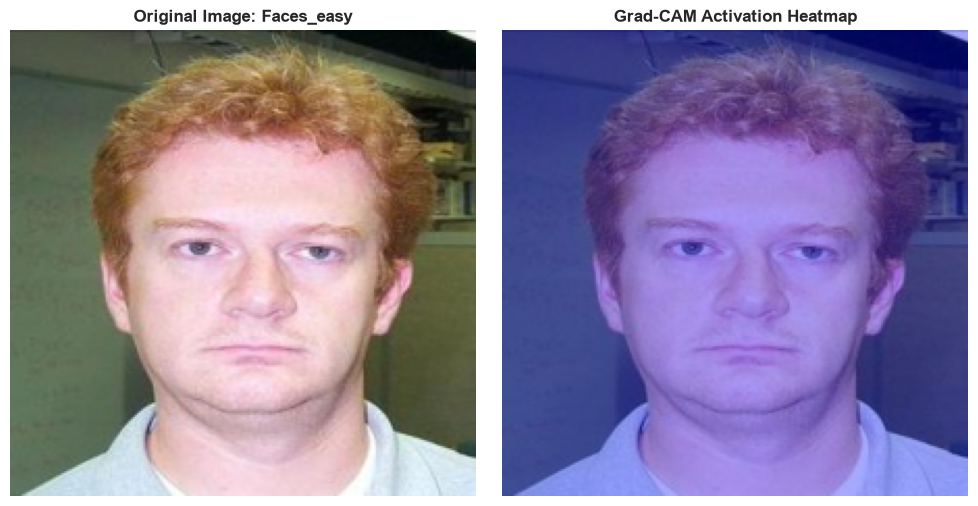

In [157]:
for param in custom_cnn.parameters():
    param.requires_grad = True

target_layer = list(custom_cnn.children())[0][8]

plot_gradcam(
    model=custom_cnn,
    target_layer=target_layer,
    dataset=test_dataloader.dataset,
    class_names=correct_class_names,
    device=device
)

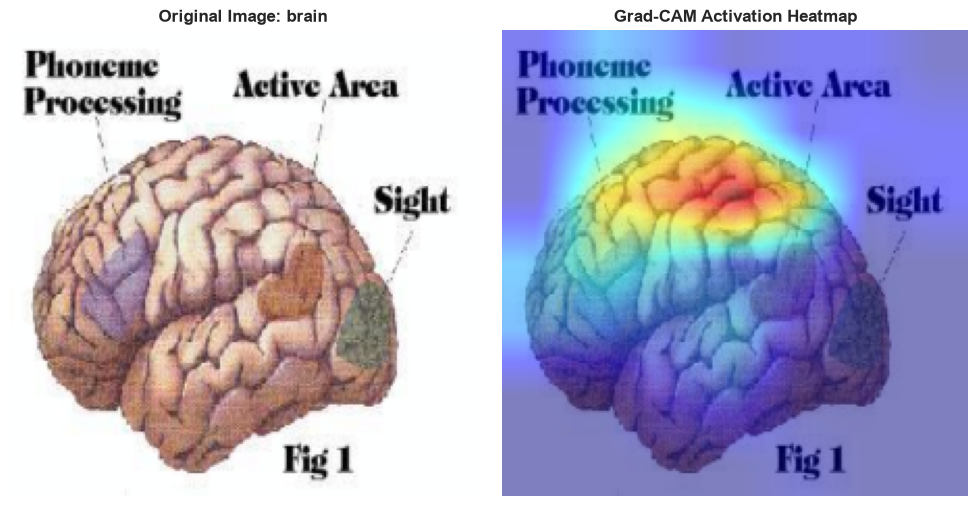

In [158]:
for param in vgg16.parameters():
    param.requires_grad = True

target_layer = vgg16.features[-1]

plot_gradcam(
    model=vgg16,
    target_layer=target_layer,
    dataset=test_dataloader.dataset,
    class_names=correct_class_names,
    device=device
)

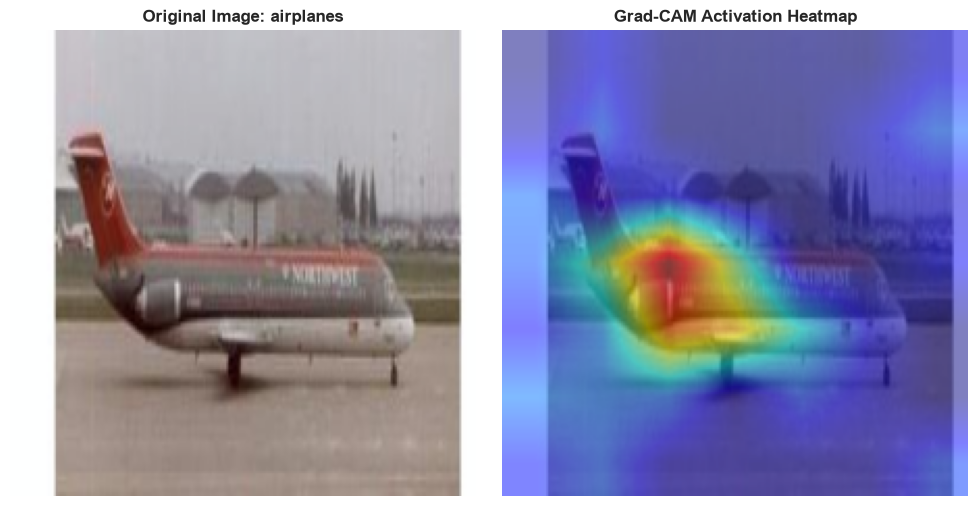

In [159]:
for param in resnet50.parameters():
    param.requires_grad = True

target_layer = resnet50.layer4[-1]

plot_gradcam(
    model=resnet50,
    target_layer=target_layer,
    dataset=test_dataloader.dataset,
    class_names=correct_class_names,
    device=device
)

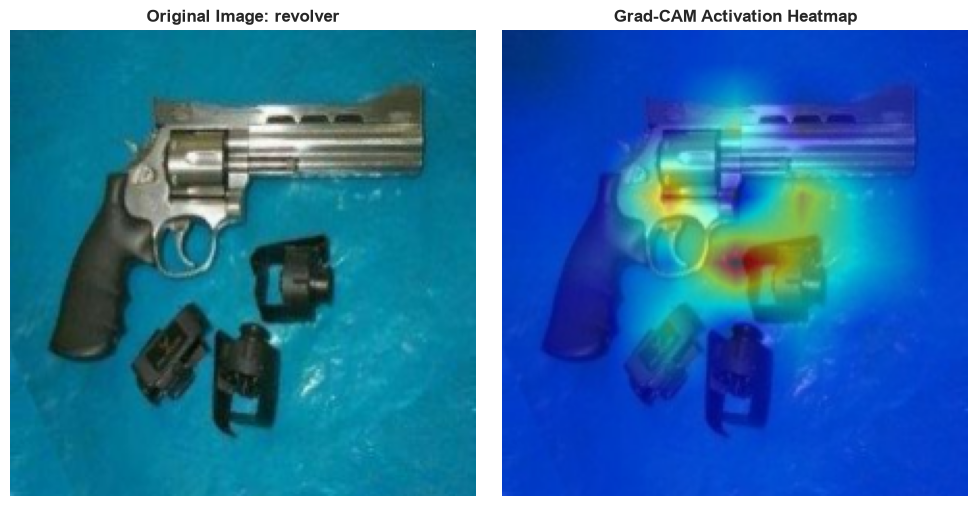

In [160]:
for param in effnetv2.parameters():
    param.requires_grad = True

target_layer = effnetv2.features[-1]

plot_gradcam(
    model=effnetv2,
    target_layer=target_layer,
    dataset=test_dataloader.dataset,
    class_names=correct_class_names,
    device=device
)

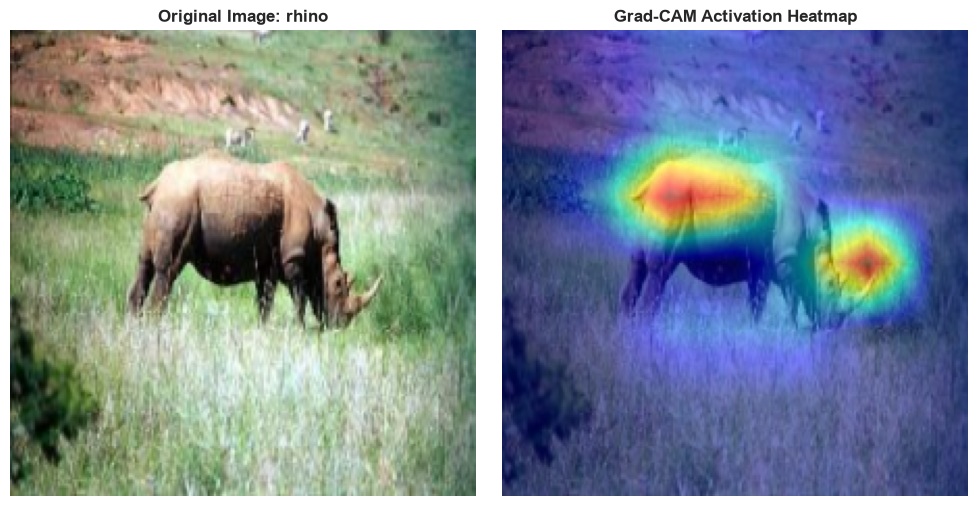

In [161]:
for param in convnext.parameters():
    param.requires_grad = True

target_layer = convnext.features[-1]

plot_gradcam(
    model=convnext,
    target_layer=target_layer,
    dataset=test_dataloader.dataset,
    class_names=correct_class_names,
    device=device
)

### Gradio Demo

In [162]:
from torchvision.transforms.functional import to_pil_image

os.makedirs("demo_images", exist_ok=True)

num_samples = 15
print(f"Saving {num_samples} random images to 'demo_images/' folder...\n")

for i in range(num_samples):
    random_idx = random.randint(0, len(test_dataloader.dataset) - 1)
    img_tensor, label_idx = test_dataloader.dataset[random_idx]
    
    class_name = correct_class_names[label_idx]
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_unnorm = img_tensor.cpu() * std + mean
    img_unnorm = torch.clamp(img_unnorm, 0, 1)
    
    img_pil = to_pil_image(img_unnorm)
    save_path = f"demo_images/sample_{i}_{class_name}.jpg"
    img_pil.save(save_path)
    
    print(f"Saved: {save_path}")

Saving 15 random images to 'demo_images/' folder...

Saved: demo_images/sample_0_cup.jpg
Saved: demo_images/sample_1_kangaroo.jpg
Saved: demo_images/sample_2_crocodile_head.jpg
Saved: demo_images/sample_3_crayfish.jpg
Saved: demo_images/sample_4_cougar_body.jpg
Saved: demo_images/sample_5_Motorbikes.jpg
Saved: demo_images/sample_6_crocodile.jpg
Saved: demo_images/sample_7_ant.jpg
Saved: demo_images/sample_8_airplanes.jpg
Saved: demo_images/sample_9_watch.jpg
Saved: demo_images/sample_10_Motorbikes.jpg
Saved: demo_images/sample_11_airplanes.jpg
Saved: demo_images/sample_12_llama.jpg
Saved: demo_images/sample_13_Faces_easy.jpg
Saved: demo_images/sample_14_ewer.jpg


In [163]:
class ConvertToRGB:
    def __call__(self, img):
        return img.convert("RGB")

gradio_transform = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [164]:
example_images = glob.glob("demo_images/*.jpg")

def predict_image(img):
    start_time = time.perf_counter()
    
    img_tensor = gradio_transform(img).unsqueeze(0).to(device)
    
    compiled_convnext.eval()
    with torch.inference_mode():
        logits = compiled_convnext(img_tensor)
        probs = torch.softmax(logits, dim=1).squeeze()
        
    # Synchronizing if on CUDA to ensure accurate hardware timing
    if "cuda" in str(device):
        torch.cuda.synchronize()
        
    pred_time = time.perf_counter() - start_time
    
    # Format top predictions
    confidences = {
        correct_class_names[i]: float(probs[i]) 
        for i in range(len(correct_class_names))
    }
    
    # Return both the probabilities and elapsed time
    return confidences, round(pred_time, 4)

In [165]:
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=[
        gr.Label(num_top_classes=5, label="Predictions"),
        gr.Number(label="Prediction Time (seconds)")
    ],
    title="CalTech-101 Image Classifier",
    description="Upload an image to see the top 5 predicted categories and inference speed.",
    examples=example_images,
    flagging_mode="never"
)

demo.launch(share=True, height=850)

* Running on local URL:  http://127.0.0.1:7866
* Running on public URL: https://5a6ef625f4b6f81f9e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Deploying to HuggingSpaces

In [166]:
import json
import shutil
import os
import torch

DEPLOY_DIR = "huggingface_space"
os.makedirs(DEPLOY_DIR, exist_ok=True)

model_to_save = getattr(compiled_convnext, "_orig_mod", convnext)
save_path = os.path.join(DEPLOY_DIR, "convnext_caltech101.pth")
torch.save(model_to_save.state_dict(), save_path)
print(f"Saved fresh model weights to: {save_path}")

# Saving class names
with open(os.path.join(DEPLOY_DIR, "class_names.json"), "w") as f:
    json.dump(correct_class_names, f)

# Copying demo images if they exist in the current working directory
if os.path.exists("demo_images"):
    shutil.copytree("demo_images", os.path.join(DEPLOY_DIR, "demo_images"), dirs_exist_ok=True)
    print("Copied demo images.")

print("\nExport complete! Files ready in ./huggingface_space")

Saved fresh model weights to: huggingface_space\convnext_caltech101.pth
Copied demo images.

Export complete! Files ready in ./huggingface_space


***